Transformer model with 11 feature (Open, High, Low, Close, Volume, SMA_10, RSI_14, ATR_14, OBV) + Sentiment Analysis

Target: Future Close Price

Most recently ran on 24-02-2026

Importing all the necessary Libraries

In [35]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import ta
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator 


Removing randomness from the model to enforce consistent results

In [36]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

In [37]:
#Loading the sentiment CSV file before passing it to the LSTM
sentiment_df = pd.read_csv("daily_apple_news_sentiment.csv")

#Converts the date column into a proper datetime object
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

Code to fetch and download data (Apple Stock Price) from Yahoo Finance every week day roughly for the past 10 years

In [38]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end = "2026-02-24")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Flatten the column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.tail())

#Trend Indicator
sma10 = SMAIndicator(data['Close'], window=10).sma_indicator()
data['SMA_10'] = data['Close'] / sma10

#Momentum Indicator
data['RSI_14'] = RSIIndicator(data['Close'], window=14).rsi()

#Volatility Indicator
atr_val = AverageTrueRange(data['High'], data['Low'], data['Close'], window=14).average_true_range()
data['ATR_14'] = atr_val / data['Close']

obv_inst = OnBalanceVolumeIndicator(close=data['Close'], volume=data['Volume'])
data['OBV'] = obv_inst.on_balance_volume().diff() / data['Volume'].rolling(20).mean()

#data.to_csv("Before.csv", index=False)

#Merge sentiment with stock data using left join (add sentiment data where available)
data = data.merge(
    sentiment_df,
    left_on="Date",
    right_on="date",
    how="left"
)

#Add a new column to the original dataframe 
#Not all days have a sentiment value so add a 0 for all missing sentiment days
data["avg_sentiment"] = data["avg_sentiment"].fillna(0)

#The model cannot differentiate between 0 being a sentiment score and 0 being no news 
#so adding a binary column that gives the model context to only look at days with news

#A binary feature that tells the model whether news exists that day
data["has_news"] = (data["avg_sentiment"] != 0).astype(int)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#data.to_csv("After.csv", index=False)

# Define feature 
price_features = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14', 'OBV']
sentiment_features = ['avg_sentiment', 'has_news']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
price_data = data[price_features].values
sentiment_data = data[sentiment_features].values
datetime_index = data['Date'].values

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_27716\2914948979.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end = "2026-02-24")
[*********************100%***********************]  1 of 1 completed

Price       Date       Close        High         Low        Open    Volume
2796  2026-02-17  263.880005  266.290009  255.539993  258.049988  58469100
2797  2026-02-18  264.350006  266.820007  262.450012  263.600006  34203300
2798  2026-02-19  260.579987  264.480011  260.049988  262.600006  30845300
2799  2026-02-20  264.579987  264.750000  258.160004  258.970001  42070500
2800  2026-02-23  266.179993  269.429993  263.380005  263.489990  37308200



C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_27716\2914948979.py:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [39]:
#Get the number of close prices
print(f"Number of close prices: {len(data)}")

Number of close prices: 2782


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [40]:
total_size = len(data)

#Defining the split size
#70% of the total data to be used for training, 15% for validation, and 15% for testing
total_size = len(data)

train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

# Split Price Data (for scaling)
#Chronogically splitting the data so first 70% is training, the next 15% is validation and the remaining 15% is testing
train_price = price_data[:train_size] #gets items from 0 to 69
val_price = price_data[train_size:train_size + val_size] #gets items from 69 to 84
test_price = price_data[train_size + val_size:] #gets items from 85 to 99

# Split Sentiment Data (no scaling needed)
train_sent = sentiment_data[:train_size]
val_sent = sentiment_data[train_size:train_size + val_size]
test_sent = sentiment_data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_price)} samples ({len(train_price)/total_size:.2%})")
print(f"Validation set : {len(val_price)} samples ({len(val_price)/total_size:.2%})")
print(f"Test set       : {len(test_price)} samples ({len(test_price)/total_size:.2%})")

print("Train:", train_price.shape)
print("Val  :", val_price.shape)
print("Test :", test_price.shape)

print("\nCheck sum:", len(train_price) + len(val_price) + len(test_price))

Total samples: 2782

Dataset sizes:
Training set   : 1947 samples (69.99%)
Validation set : 417 samples (14.99%)
Test set       : 418 samples (15.03%)
Train: (1947, 9)
Val  : (417, 9)
Test : (418, 9)

Check sum: 2782


Normalizing the data using a Min-Max Scaler. But only using only the training data as the scaler to prevent data leaks. 

In [41]:
#Calculating the number of features, and creating a seperate scaler for each feature
num_features = train_price.shape[1]
scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in range(num_features)]

#Fit each scaler on only the training data for that specific column - this avoids data leaks
#Here we just calculate and store the min and max values for each feature
for i, scaler in enumerate(scalers):
    scaler.fit(train_price[:, [i]])

#Transform each column individually using its corresponding scaler
#Transforming means actually applying the MinMax formula to get new values between 0-1
#np.hstack then stacks the scaled columns back together horizontally
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

#All three datasets are transformed using the scalers fitted on the training data
train_price_scaled = scale_data(train_price, scalers)
val_price_scaled = scale_data(val_price, scalers)
test_price_scaled = scale_data(test_price, scalers)

print("Train scaled min/max:", train_price_scaled.min(), train_price_scaled.max())
print("Val   scaled min/max:", val_price_scaled.min(), val_price_scaled.max())
print("Test  scaled min/max:", test_price_scaled.min(), test_price_scaled.max())

Train scaled min/max: 0.0 1.0000000000000004
Val   scaled min/max: -0.027889103643613328 1.249778004919281
Test  scaled min/max: -0.3336528583304499 1.6957202105232974


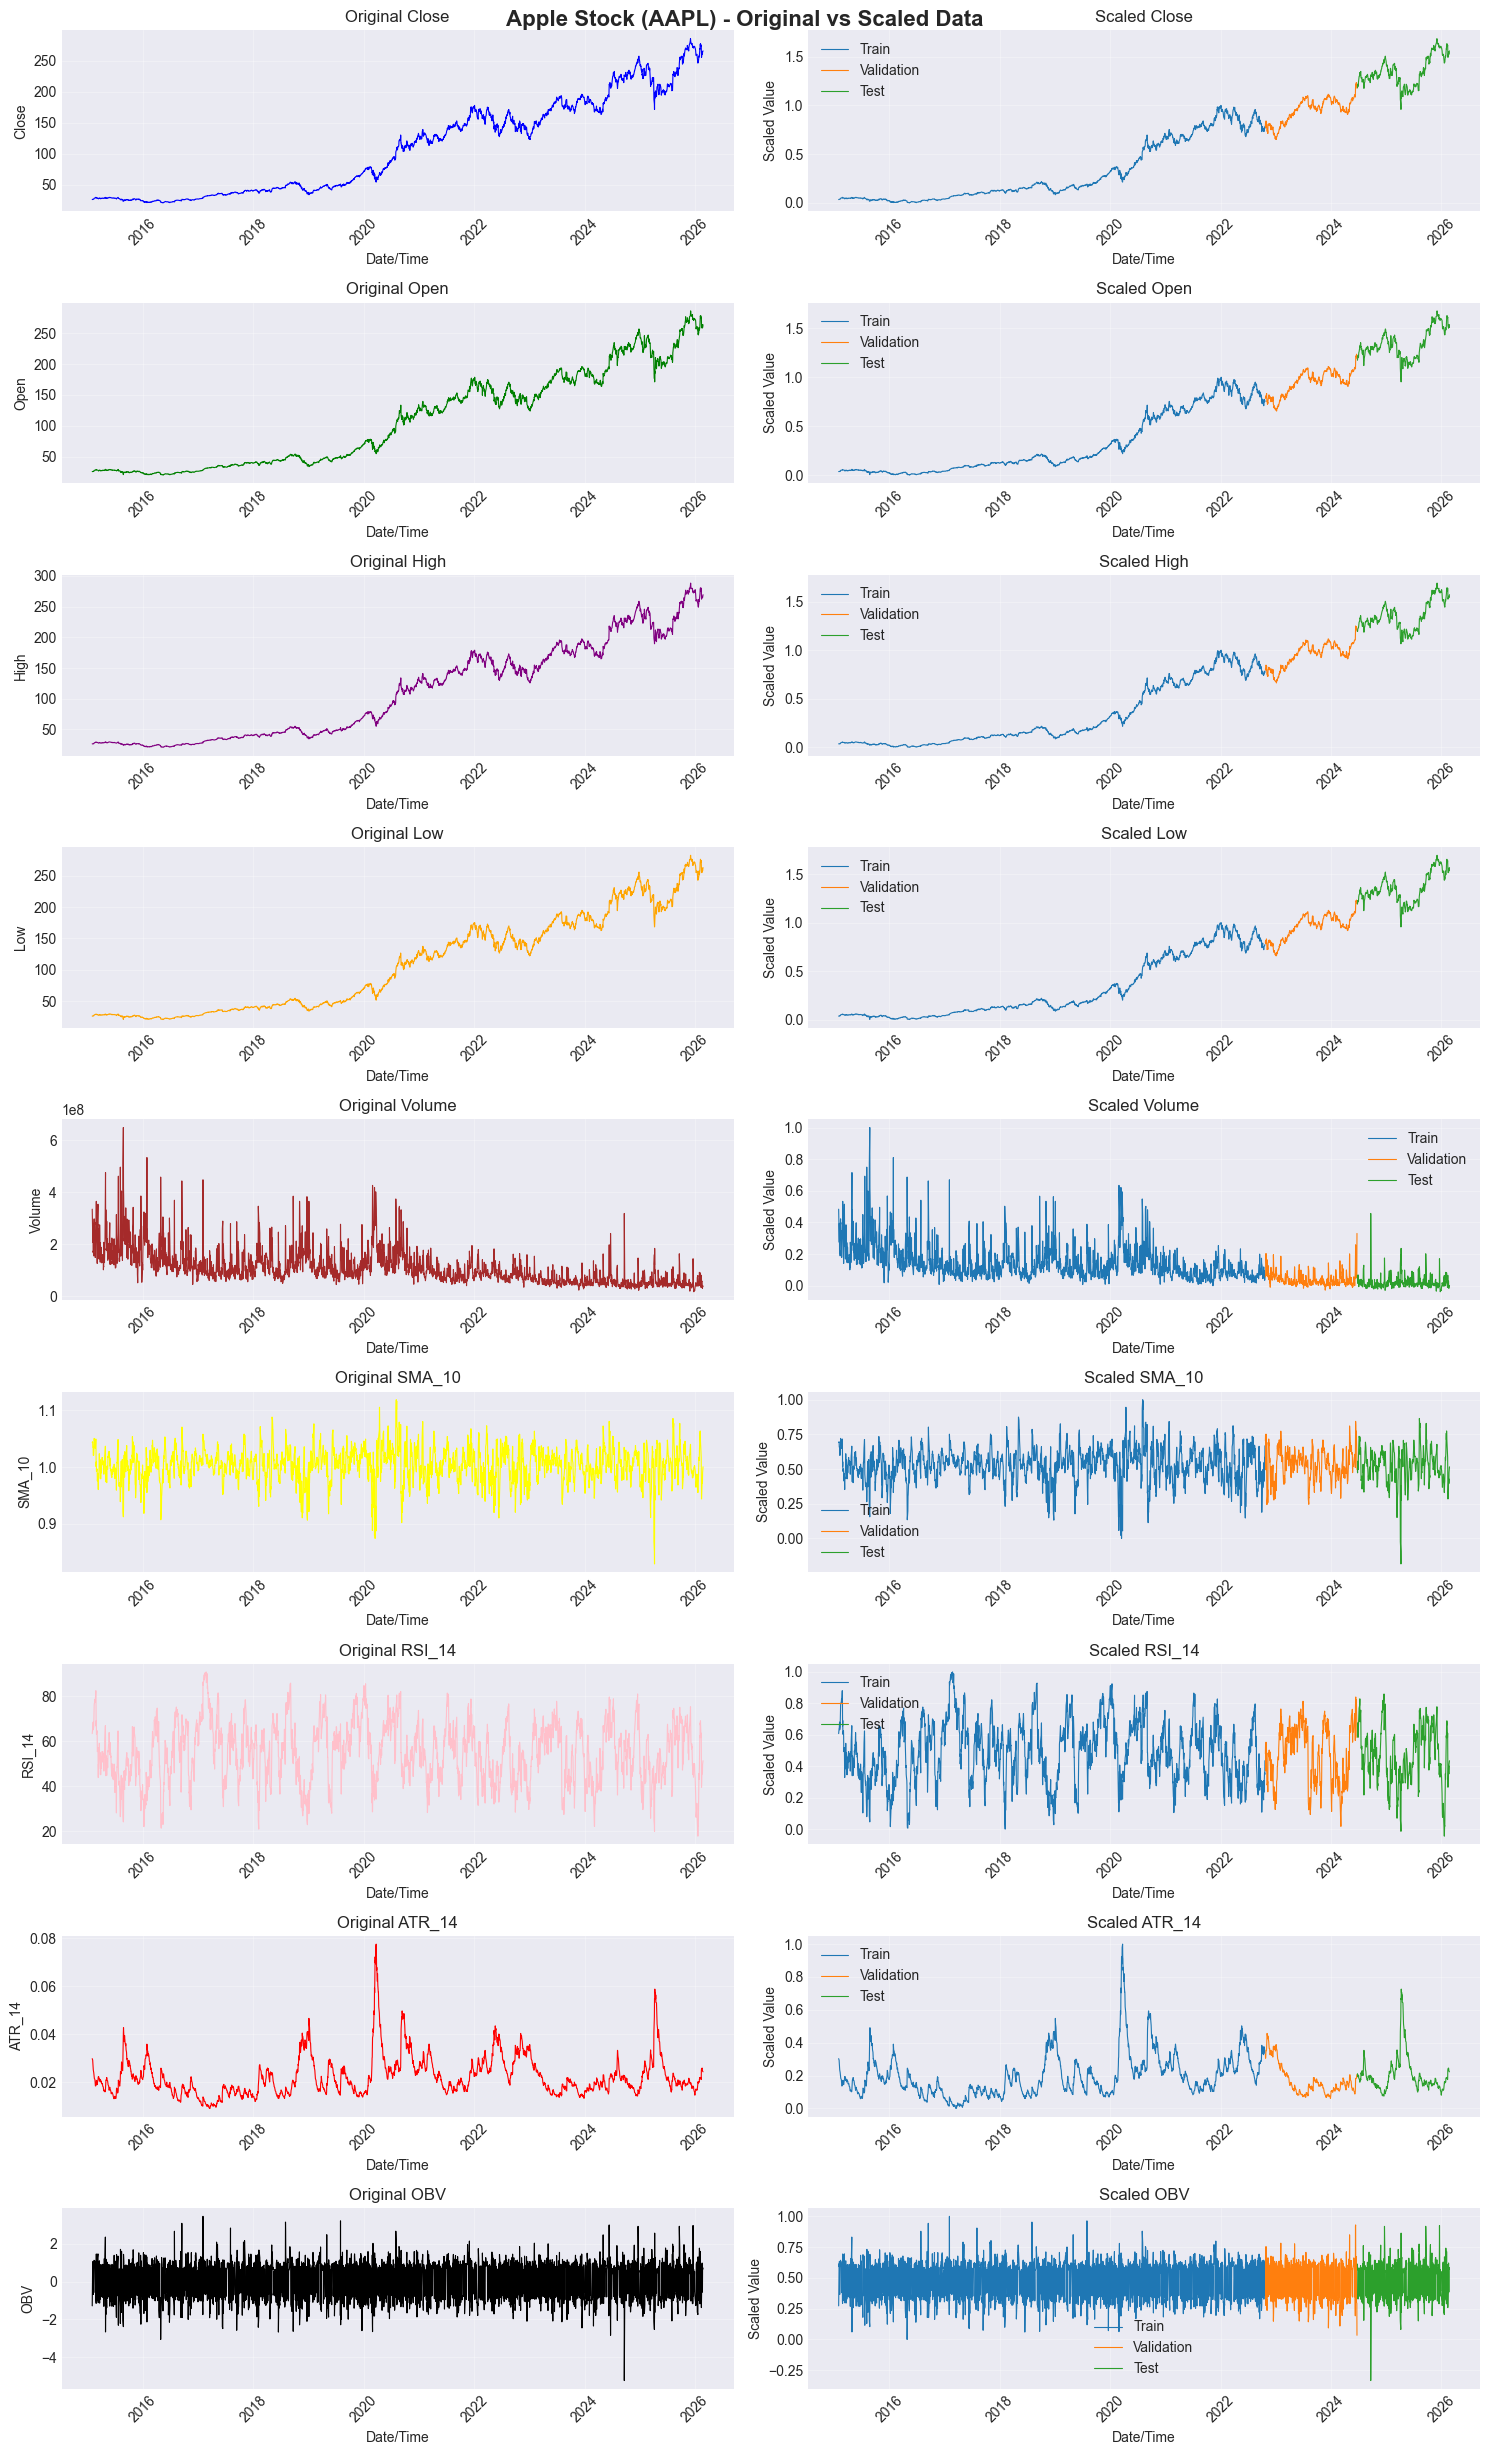

In [42]:
# Reconstructing datetime splits to match data splits
datetime_train = datetime_index[:train_size]
datetime_val   = datetime_index[train_size:train_size + val_size]
datetime_test  = datetime_index[train_size + val_size:]

num_features = train_price.shape[1]

# Create 8x2 subplot layout for both features
fig, axes = plt.subplots(num_features, 2, figsize=(15, 25))
fig.suptitle(
    'Apple Stock (AAPL) - Original vs Scaled Data',
    fontsize=16,
    fontweight='bold'
)

feature_titles = ['Close', 'Open', 'High', 'Low', 'Volume', 'SMA_10', 'RSI_14', 'ATR_14', 'OBV']
colors = ['blue', 'green', 'purple', 'orange', 'brown', 'yellow', 'pink', 'red', 'black']

for i in range(num_features):
    # Original
    axes[i, 0].plot(datetime_index, price_data[:, i], color=colors[i], linewidth=0.8)
    axes[i, 0].set_title(f'Original {feature_titles[i]}')
    axes[i, 0].set_xlabel('Date/Time')
    axes[i, 0].set_ylabel(feature_titles[i])
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Scaled
    axes[i, 1].plot(datetime_train, train_price_scaled[:, i], label='Train', linewidth=0.8)
    axes[i, 1].plot(datetime_val, val_price_scaled[:, i], label='Validation', linewidth=0.8)
    axes[i, 1].plot(datetime_test, test_price_scaled[:, i], label='Test', linewidth=0.8)
    axes[i, 1].set_title(f'Scaled {feature_titles[i]}')
    axes[i, 1].set_xlabel('Date/Time')
    axes[i, 1].set_ylabel('Scaled Value')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

In [43]:
# Stack scaled prices with unscaled sentiment
train_final = np.hstack([train_price_scaled, train_sent])
val_final = np.hstack([val_price_scaled, val_sent])
test_final = np.hstack([test_price_scaled, test_sent])

all_cols = price_features + sentiment_features

datasets = {
    "Train": train_final,
    "Validation": val_final,
    "Test": test_final
}

#Loop through the dictionary items
for name, dataset_array in datasets.items():
    rows, cols = dataset_array.shape
    print(f"{name} Set - Rows: {rows}, Columns: {cols}")

Train Set - Rows: 1947, Columns: 11
Validation Set - Rows: 417, Columns: 11
Test Set - Rows: 418, Columns: 11


Creating a Sliding Window to feed inputs to my model

In [44]:
def create_multifeature_dataset_with_context(data, time_step, context_data = None):

    if context_data is not None:
        data = np.vstack([context_data[-time_step:], data])

    X, y = [] ,[]

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])  #here we grab all columns and rows per timesteps (rows 0-24 first time)
        y.append(data[i + time_step, 0])  #here we only predict the Close price (row 25)

    #Convert the lists to NumPy arrays for compatibility with neural network frameworks
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_final, time_step)
X_val, y_val     = create_multifeature_dataset_with_context(val_final, time_step, context_data=train_final)
X_test, y_test   = create_multifeature_dataset_with_context(test_final, time_step, context_data=val_final)

# Check shapes
print("Shapes of LSTM datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")


Shapes of LSTM datasets:
X_train: (1922, 25, 11), y_train: (1922,)
X_val  : (417, 25, 11), y_val  : (417,)
X_test : (418, 25, 11), y_test : (418,)


Positional Encoding Function - Classic Sinusoidal (Fixed):
Used to provide the model with extra information about time steps as self-attetion alone doesn't know sequence order

In [45]:
def get_positional_encoding(time_step, d_model):

    #Create a position array counting from day 0 to the size of our window (25) and covert the 1D array into a 2D array
    pos = np.arange(time_step)[:, np.newaxis]
    
    #Create a dimensions array which is the same length as our embedding dimensions (64)
    i = np.arange(d_model)[np.newaxis, :]

    #Compute angle rates
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))

    #Combine positions and angle rates
    angle_rads = pos * angle_rates

    #Apply sin to even columns and cosine to odd columns
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = angle_rads[np.newaxis, ...]

    return tf.cast(pos_encoding, dtype=tf.float32)


Transformer Model Architecture

In [46]:
#Build the Transformer encoder
num_features = X_train.shape[2]
d_model = 64
num_heads = 4
ff_dim = 128

#Building the input preojection embedding - projecting the original features into a higher-dimensional space
inputs = Input(shape=(time_step, num_features))
x = Dense(d_model)(inputs)

#Add Positional Encoding - inject temporal information so each day's vector is now distinct
pos_enc = get_positional_encoding(time_step, d_model)
x = Lambda(lambda x: x + pos_enc)(x) #we use Lamda here so training and evaluation work correctly 

#Building the Transformer Encoder Blocks
for _ in range(2): 

    #Multi-Head Self-Attentio
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads, )(x, x, use_causal_mask=True) 
    attn_output = Dropout(0.1)(attn_output)

    #Residual Connection + Layer Norm
    x = LayerNormalization(epsilon=1e-4)(x + attn_output)

    #Feed-Forward Network (FFN)
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(d_model)(ff_output)
    ff_output = Dropout(0.1)(ff_output)

    #Residual Connection + Layer Norm
    x = LayerNormalization(epsilon=1e-4)(x + ff_output)

#Extract the last day for regression and convert it to a single prediction
x = Lambda(lambda x: x[:, -1, :])(x) 
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="linear")(x)

#Comile the model
model = Model(inputs=inputs, outputs=outputs)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss='mse', metrics=['mae'])


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    shuffle=False, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0498 - mae: 0.1694 - val_loss: 0.0062 - val_mae: 0.0625 - learning_rate: 1.0000e-04
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0269 - mae: 0.1258 - val_loss: 0.0050 - val_mae: 0.0571 - learning_rate: 1.0000e-04
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0210 - mae: 0.1120 - val_loss: 0.0036 - val_mae: 0.0479 - learning_rate: 1.0000e-04
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0176 - mae: 0.1017 - val_loss: 0.0034 - val_mae: 0.0447 - learning_rate: 1.0000e-04
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0169 - mae: 0.0976 - val_loss: 0.0036 - val_mae: 0.0500 - learning_rate: 1.0000e-04
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0173 - mae: 0.0965 - val_loss: 0.0038 - val_mae: 0.0521 - learning_rate: 1.0000e-04
Epoch 7/100
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0293 - mae: 0.1243
Epoch 7: ReduceLROnPlateau re

A graph to visulzise the training process - to check if the model is overfitting

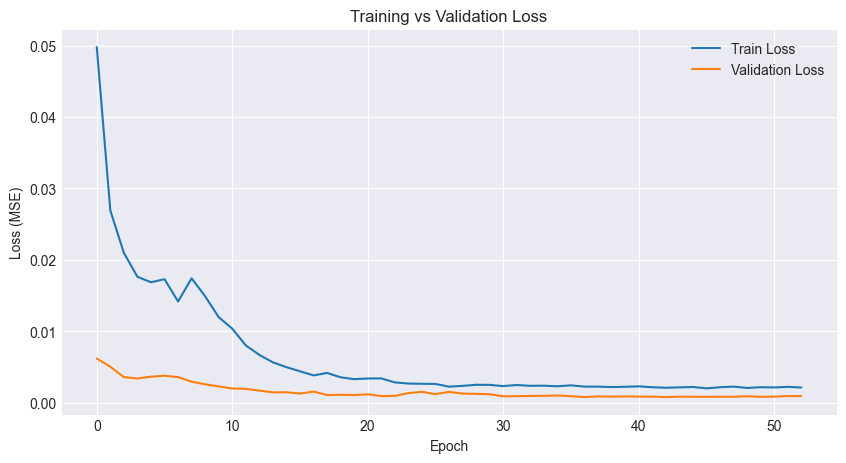

In [47]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [48]:
predictions_scaled = model.predict(X_test)

#Inverse transform to get actual dollar values
predictions = scalers[0].inverse_transform(predictions_scaled)
y_test_unscaled = scalers[0].inverse_transform(y_test.reshape(-1, 1))

#Flatten for easier handling
predictions = predictions.flatten()
y_test_unscaled = y_test_unscaled.flatten()

#Calculate metrics

rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mae  = mean_absolute_error(y_test_unscaled, predictions)

print(f"\nUnscaled Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Unscaled Mean Absolute Error (MAE)    : ${mae:.2f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

Unscaled Root Mean Squared Error (RMSE): $7.54
Unscaled Mean Absolute Error (MAE)    : $5.76


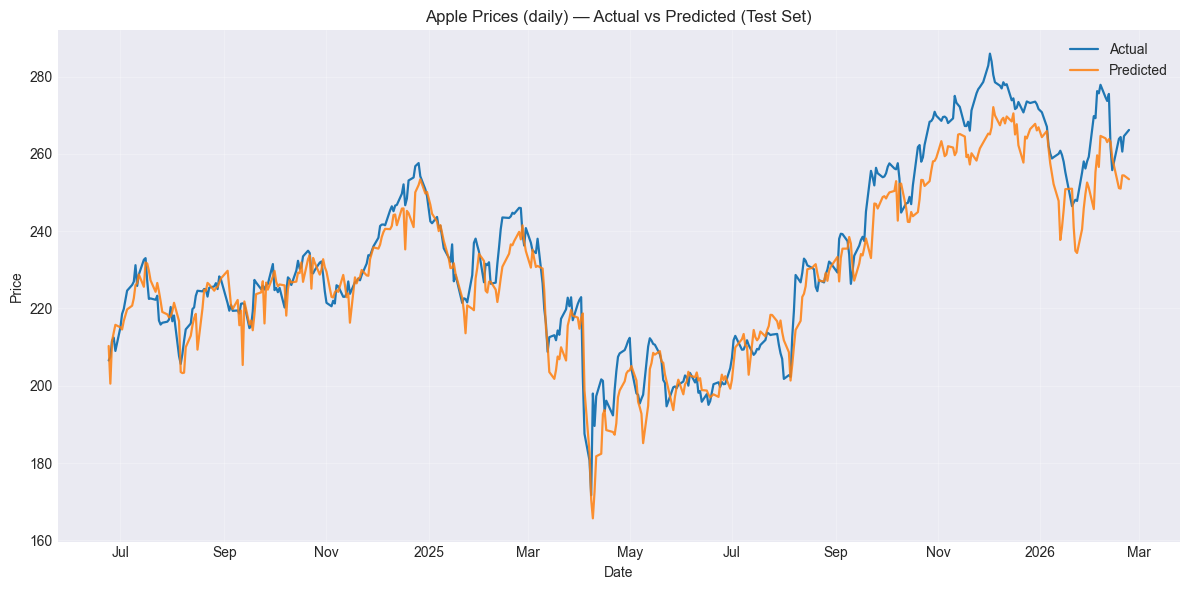

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates_test = datetime_index[-len(predictions):]

#Plot Actual vs Predicted
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_unscaled, label="Actual", linewidth=1.6)
plt.plot(dates_test, predictions, label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Prices (daily) — Actual vs Predicted (Test Set)")
plt.ylabel("Price")
plt.xlabel("Date")
plt.legend()

# Format dates nicely
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Checking the Accuracy of my model:

In [50]:
# --- Directional Accuracy ---

# Actual and predicted price changes
actual_direction = np.sign(np.diff(y_test_unscaled))
predicted_direction = np.sign(np.diff(predictions))

# Directional accuracy
directional_accuracy = np.mean(actual_direction == predicted_direction)

print(f"Directional Accuracy: {directional_accuracy * 100:.2f}%") 

Directional Accuracy: 53.00%


In [51]:
# --- MAPE-based Accuracy ---

mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100
accuracy_mape = 100 - mape

print(f"MAPE: {mape:.2f}%")
print(f"MAPE-based Accuracy: {accuracy_mape:.2f}%")

MAPE: 2.43%
MAPE-based Accuracy: 97.57%
